# 集群混合并行训练 · 实操：MindSpeed 训练配置与启动流程

前面三章的理论课介绍了数据并行、张量并行、流水线并行，介绍了 AllReduce 和 HCCL，以及 MindSpeed 的工程流程。本实验把它们全部串起来——**在真实的昇腾 910B NPU 上，完整执行一次大模型的多卡分布式训练**。

## 你将学到

- 把 HuggingFace 权重转换成 MindSpeed 能加载的 Megatron 格式
- 把原始文本数据预处理成训练需要的二进制格式
- 用 torchrun 拉起多卡训练，理解每个参数的含义
- 从训练日志中提取 loss、吞吐等关键指标

## 实验环境

- **平台**：华为云 ModelArts + JupyterLab
- **硬件**：Ascend 910B NPU，单卡 64GB HBM2e（本节演示用单机 4 卡）
- **软件**：MindSpeed-LLM 2.2.0（镜像预装，免装环境）
- **模型**：Qwen2.5-7B（通义千问 70 亿参数基座模型）

> 学习建议：先跟着 notebook 从头到尾完整跑一遍，建立整体流程印象；分布式训练参数很多，不要求第一次全部理解，跑通后再回头逐项消化。

## 五步闭环：实验流程总览

一次完整的多卡训练，从头到尾就五步：

| 步骤 | 做什么 | 一句话理解 |
|------|--------|-----------|
| **Step 0** | 准备权重和数据 | 下载权重（15GB）和数据集（24MB） |
| **Step 1** | 检查环境 | 确认 NPU 和通信正常 |
| **Step 2** | 权重转换 | 把权重切成 TP×PP 块，方便多卡加载 |
| **Step 3** | 数据预处理 | 把文本转成数字序列（token） |
| **Step 4** | 启动训练 | 生成脚本，终端执行 |
| **Step 5** | 解析日志 | 确认 loss 是否下降、吞吐是否稳定 |

---
## Step 0：准备权重和数据

需要提前准备两项资源：

- **模型权重**：Qwen2.5-7B，约 15GB，从 ModelScope（魔搭社区）下载
- **训练数据**：Alpaca 数据集，约 24MB

都下载到 `/home/ma-user/work/` 目录——这是 ModelArts 的持久化目录，停止实例后不丢失。

In [1]:
# 屏蔽不必要的警告（保持输出简洁）
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['PYTHONWARNINGS'] = 'ignore'          # 传递给后续 Python 子进程
os.environ['PIP_DISABLE_PIP_VERSION_CHECK'] = '1'

# 先定义好所有路径（后面每一步都会用到）
from pathlib import Path

WORK_DIR = Path('/home/ma-user/work/l06_workspace')   # 所有实验文件的根目录
WORK_DIR.mkdir(parents=True, exist_ok=True)

MSLLM_ROOT = Path('/home/ma-user/MA_Turbo/src/open_source/MindSpeed-LLM')
HF_DIR      = WORK_DIR / 'Qwen2.5-7B'         # HuggingFace 权重
RAW_DATA    = WORK_DIR / 'alpaca.parquet'     # 原始训练数据
DATA_PREF   = WORK_DIR / 'alpaca'             # 预处理输出前缀
TOTAL       = 4                    # 总卡数
TP, PP      = 2, 2                 # 张量并行 / 流水线并行（4 卡 = TP2 x PP2，DP=1）
# 显存依据：每卡约 1.9B 参数，模型+优化器约 38GB，加激活与运行开销约 42GB / 64GB，余量充足
MCORE_DIR   = WORK_DIR / f'qwen_mcore_tp{TP}_pp{PP}'
print('工作目录：', WORK_DIR)


工作目录： /home/ma-user/work/l06_workspace


### 这套并行配置怎么读

4 张卡按 **TP=2 × PP=2** 铺开，DP=1：

- **TP=2（张量并行）**：每层权重切 2 份，两张卡各算一半，每卡 14 个注意力头。
- **PP=2（流水线并行）**：28 层模型切成两个 stage（前 14 层 / 后 14 层），数据像流水线一样流过两段。流水线会引入等待（气泡），气泡占比约 (PP-1)/GAS = 1/64 ≈ 1.6%，很小。
- **DP=1 时的数据并行去哪了？** 由 GAS 承担。GBS=64、MBS=1、DP=1，所以 GAS = 64/(1×1) = 64——每张卡连续做 64 次前向+反向、累积梯度后才更新一次参数。**梯度累积就是串行版的数据并行**：多卡 DP 是把 64 个样本分给多张卡并行算，GAS 是单卡分 64 批串行算，两种方式得到的有效批次相同。

选 TP=2 PP=2 而不是 TP=4 PP=1，是为了让张量并行和流水线并行都在场；DP 用 GAS 体现。三种并行策略，这套配置一个不缺。

### 0.1 下载 Qwen2.5-7B 权重

In [2]:
# 安装 modelscope（ModelArts 镜像未预装）
!pip install modelscope -q

In [3]:
# 下载 Qwen2.5-7B 权重（约15GB）
# 先检查是否已下载完整，完整则跳过
_need_download = True
if (HF_DIR / 'config.json').is_file():
    _safetensors = list(HF_DIR.glob('*.safetensors'))
    if len(_safetensors) >= 4:
        _need_download = False
        print('权重已存在（%d 个 safetensors），跳过下载' % len(_safetensors))

if _need_download:
    import logging
    import threading
    import time
    from IPython.display import clear_output

    # 压制 SDK 自身的进度输出（tqdm 在 JupyterLab 中每次刷新都会新增一行，会刷屏）
    os.environ['MODELSCOPE_LOG_LEVEL'] = str(logging.ERROR)  # 必须数字字符串：modelscope 用 int() 解析，'ERROR' 会报错
    os.environ['MODELSCOPE_NO_DEPRECATION_WARNINGS'] = '1'
    os.environ['TQDM_DISABLE'] = '1'

    # 下载放后台线程；主线程每 5 秒统计目录实际大小，clear_output 单行刷新进度
    _err = []

    def _worker():
        try:
            from modelscope.hub.snapshot_download import snapshot_download
            snapshot_download('Qwen/Qwen2.5-7B', local_dir=str(HF_DIR))
        except Exception as e:
            _err.append(e)

    _t = threading.Thread(target=_worker)
    _t.start()

    _TARGET_GB = 15.2   # Qwen2.5-7B 权重约 15.2GB
    _start = time.time()
    while _t.is_alive():
        time.sleep(5)
        _size = sum(f.stat().st_size for f in HF_DIR.rglob('*') if f.is_file()) if HF_DIR.exists() else 0
        _pct = min(100.0, _size / 1e9 / _TARGET_GB * 100)
        _speed = (_size / 1e9) / max(1, time.time() - _start)
        clear_output(wait=True)   # 清掉旧输出只留这一行，进度实时且不堆积
        print('下载中：%.1f GB / 约 %.1f GB（%.0f%%，%.1f MB/s）'
              % (_size / 1e9, _TARGET_GB, _pct, _speed * 1024))
    _t.join()
    if _err:
        raise _err[0]

    clear_output(wait=True)
    print('下载完成：', HF_DIR)
    _final = list(HF_DIR.glob('*.safetensors'))
    print('safetensors 文件数：%d（应为 4）' % len(_final))

下载完成： /home/ma-user/work/l06_workspace/Qwen2.5-7B
safetensors 文件数：4（应为 4）


下载完成后，查看权重目录：

In [4]:
# 查看下载的权重文件
!ls -lh {HF_DIR} | head -20

total 15G
-rw-r----- 1 ma-user ma-group  12K Aug 15 19:46 LICENSE
-rw-r----- 1 ma-user ma-group 3.8K Aug 15 19:48 README.md
-rw-r----- 1 ma-user ma-group  686 Aug 15 19:46 config.json
-rw-r----- 1 ma-user ma-group    2 Aug 15 19:46 configuration.json
-rw-r----- 1 ma-user ma-group  138 Aug 15 19:46 generation_config.json
-rw-r----- 1 ma-user ma-group 1.6M Aug 15 19:46 merges.txt
-rw-r----- 1 ma-user ma-group 3.7G Aug 15 19:48 model-00001-of-00004.safetensors
-rw-r----- 1 ma-user ma-group 3.6G Aug 15 19:48 model-00002-of-00004.safetensors
-rw-r----- 1 ma-user ma-group 3.6G Aug 15 19:48 model-00003-of-00004.safetensors
-rw-r----- 1 ma-user ma-group 3.4G Aug 15 19:48 model-00004-of-00004.safetensors
-rw-r----- 1 ma-user ma-group  28K Aug 15 19:48 model.safetensors.index.json
-rw-r----- 1 ma-user ma-group 6.8M Aug 15 19:48 tokenizer.json
-rw-r----- 1 ma-user ma-group 7.1K Aug 15 19:48 tokenizer_config.json
-rw-r----- 1 ma-user ma-group 2.7M Aug 15 19:48 vocab.json


三个关键文件：
- `config.json`：架构信息（层数、维度等）
- `*.safetensors`：权重数据（4 个文件，每个约 3.8GB）
- `tokenizer.json`：分词器

### 0.2 下载训练数据

In [5]:
# 下载 Alpaca 数据集（约 24MB，下载耗时可忽略）
# 主链接 huggingface.co（国内可能连不上），自动回退 hf-mirror 镜像
ALPACA_URLS = [
    'https://huggingface.co/datasets/tatsu-lab/alpaca/resolve/main/data/train-00000-of-00001-a09b74b3ef9c3b56.parquet',
    'https://hf-mirror.com/datasets/tatsu-lab/alpaca/resolve/main/data/train-00000-of-00001-a09b74b3ef9c3b56.parquet',
]
for _url in ALPACA_URLS:
    !wget -q -c --timeout=30 --tries=2 {_url} -O {RAW_DATA}
    if RAW_DATA.exists() and RAW_DATA.stat().st_size > 1024:
        print('下载成功：', _url.split('/')[2])
        break
!ls -lh {RAW_DATA} | head -20


下载成功： huggingface.co
-rw-r----- 1 ma-user ma-group 24M Aug 15 19:48 /home/ma-user/work/l06_workspace/alpaca.parquet


下载会自动依次尝试 huggingface 主链接和 hf-mirror 镜像，都失败时（极少见）在终端手动下载后放置到 RAW_DATA 路径。

---

## Step 1：检查环境

确认两件事：
1. **NPU 硬件就绪**——能看到几张卡
2. **软件栈正常**——torch_npu 能不能调用 NPU

In [6]:
# 查看所有 NPU 的状态（类似 nvidia-smi 的昇腾版本）
!npu-smi info

+------------------------------------------------------------------------------------------------+
| npu-smi 25.5.1                   Version: 25.5.1                                               |
+---------------------------+---------------+----------------------------------------------------+
| NPU   Name                | Health        | Power(W)    Temp(C)           Hugepages-Usage(page)|
| Chip                      | Bus-Id        | AICore(%)   Memory-Usage(MB)  HBM-Usage(MB)        |
+===========================+===============+====================================================+
| 1     910B2               | OK            | 97.9        49                0    / 0             |
| 0                         | 0000:01:00.0  | 0           0    / 0          3404 / 65536         |
+===========================+===============+====================================================+
| 2     910B2               | OK            | 102.3       49                0    / 0             |
| 0       

你应该看到一个表格，列出每张 NPU 的编号、型号、显存占用、温度等。确认：
- 卡数和你购买的规格一致（4 卡实例看到 4 张，单卡显存 64GB）
- 每张卡的显存基本空闲（训练前应该接近 0）
- 没有残留进程占用

In [7]:
# 确认 torch_npu 可用，统计 NPU 数量
import torch
import torch_npu
print('可用 NPU 数量：', torch.npu.device_count())

可用 NPU 数量： 4


### 验证多卡通信

分布式训练的命脉是通信。在启动 torchrun 之前，先确认卡之间能正常做 AllReduce。

思路很简单：每张卡放一个值（rank0 放 1，rank1 放 2...），做一次 AllReduce 求和，校验结果是否正确。4 张卡时，结果应该是 1+2+3+4=10。

In [8]:
# 验证多卡通信（用 torch_npu 做 AllReduce）
n_npu = torch.npu.device_count()
print('当前 NPU 数量：', n_npu)

if n_npu < 2:
    print('只有 1 张卡，跳过通信测试（本实验用 4 卡实例，正常应显示 4 张）')
else:
    # 写一个临时验证脚本，用 torchrun 拉起
    check_script = WORK_DIR / 'hccl_check.py'
    check_script.write_text(
        "import os, torch, torch_npu\n"
        "import torch.distributed as dist\n"
        "local_rank = int(os.environ['LOCAL_RANK'])\n"
        "rank = int(os.environ['RANK'])\n"
        "world = int(os.environ['WORLD_SIZE'])\n"
        "torch.npu.set_device(local_rank)\n"
        "dist.init_process_group(backend='hccl')\n"
        "t = torch.ones(1024, 1024, device='npu:%d' % local_rank) * (rank + 1)\n"
        "dist.all_reduce(t, op=dist.ReduceOp.SUM)\n"
        "expected = sum(r + 1 for r in range(world))\n"
        "ok = torch.allclose(t, torch.ones(1024, 1024, device='npu:%d' % local_rank) * expected)\n"
        "print('rank %d/%d: AllReduce correct = %s' % (rank, world, 'OK' if ok else 'FAIL'), flush=True)\n"
        "dist.barrier()\n"
        "if rank == 0:\n"
        "    print('=== HCCL check %s ===' % ('PASSED' if ok else 'FAILED'), flush=True)\n"
        "dist.destroy_process_group()\n",
        encoding='utf-8',
    )
    cmd = ('source /usr/local/Ascend/ascend-toolkit/set_env.sh 2>/dev/null && '
           'export HCCL_WHITELIST_DISABLE=1 && '
           'export HCCL_CONNECT_TIMEOUT=7200 && '
           'torchrun --nproc_per_node %d --master_addr 127.0.0.1 --master_port 29500 %s' % (n_npu, check_script))
    print('执行通信测试...')
    !{cmd}

当前 NPU 数量： 4
执行通信测试...
W0815 19:48:52.786000 10272 site-packages/torch/distributed/run.py:766] 
W0815 19:48:52.786000 10272 site-packages/torch/distributed/run.py:766] *****************************************
W0815 19:48:52.786000 10272 site-packages/torch/distributed/run.py:766] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0815 19:48:52.786000 10272 site-packages/torch/distributed/run.py:766] *****************************************
rank 0/4: AllReduce correct = OK
rank 1/4: AllReduce correct = OK
rank 3/4: AllReduce correct = OK
rank 2/4: AllReduce correct = OK
=== HCCL check PASSED ===


---

## Step 2：权重转换（HF → Megatron）

这是整个实验**最容易被忽视、却最容易出问题**的一步。

> 对应《MindSpeed 分布式训练流程》PPT 五步闭环的第 ② 步：权重转换（HuggingFace → Megatron 格式）。

### 为什么要转换？

HuggingFace 格式的权重，是把所有参数存在一起的整块。但多卡训练时，需要把权重**按张量并行（TP）切列、按流水线并行（PP）切层**，切分后每张卡只加载属于自己的分片。

```
HuggingFace 权重（整块）          Megatron 权重（切分后）
+------------------+    转换     +------+------+
|                  |  =======>  | TP0  | TP1  |                （按列切分）
|    7B 参数       |             +------+------+
|                  |             | PP Stage0 | PP Stage1 |     （按层切分）
+------------------+             +----------+----------+
```

### 关键：转换的 TP/PP 必须和训练完全一致

本实验的配置是 **TP=2 PP=2**，所以转换时也必须是 `--target-tensor-parallel-size 2 --target-pipeline-parallel-size 2`。如果不一致，训练加载权重时会因为张量形状不匹配直接报错。

### 定位 MindSpeed-LLM 仓库

转换脚本 `convert_ckpt.py` 在 MindSpeed-LLM 仓库的根目录。先确认它存在：


In [9]:
# 使用预装的 MindSpeed-LLM，并补齐 Megatron-LM 依赖
import subprocess, sys

# 镜像预装了一套版本自洽的 MindSpeed-LLM + MindSpeed core，只使用固定预装路径
print('MindSpeed-LLM 仓库:', MSLLM_ROOT)
assert (MSLLM_ROOT / 'convert_ckpt.py').is_file(), '预装 MindSpeed-LLM 不完整，请确认镜像为 mindspeed_llm_2.2.0'

# 把仓库根目录加入 Python 路径（megatron 要从这里加载）
if str(MSLLM_ROOT) not in sys.path:
    sys.path.insert(0, str(MSLLM_ROOT))

# 补齐 Megatron-LM（镜像预装的 MindSpeed 依赖它，但没装到位）
try:
    import megatron
    print('megatron: 已就绪')
except ImportError:
    print('megatron 缺失，正在按官方流程安装...')
    # 官方 install_guide: clone Megatron-LM + checkout core_v0.12.1 + cp -r megatron
    megatron_src = WORK_DIR / 'Megatron-LM'
    if not (megatron_src / 'megatron' / '__init__.py').is_file():
        if megatron_src.exists():
            import shutil; shutil.rmtree(megatron_src)
        subprocess.run(['git', 'clone', 'https://github.com/NVIDIA/Megatron-LM.git', str(megatron_src)], check=True, capture_output=True)
    subprocess.run(['git', '-C', str(megatron_src), 'checkout', 'core_v0.12.1'], check=True)
    # 拷贝到 MindSpeed-LLM 目录（官方要求）
    subprocess.run(['cp', '-r', str(megatron_src / 'megatron'), str(MSLLM_ROOT / 'megatron')], check=True)
    import megatron
    print('megatron: 安装完成')

# 验证关键脚本存在（不触发 mindspeed 初始化，避免 patch 冲突）
print('convert_ckpt.py:', (MSLLM_ROOT / 'convert_ckpt.py').is_file())
print('preprocess_data.py:', (MSLLM_ROOT / 'preprocess_data.py').is_file())
print('pretrain_gpt.py:', (MSLLM_ROOT / 'pretrain_gpt.py').is_file())
print('环境就绪，可以继续下一步')

MindSpeed-LLM 仓库: /home/ma-user/MA_Turbo/src/open_source/MindSpeed-LLM
megatron: 已就绪
convert_ckpt.py: True
preprocess_data.py: True
pretrain_gpt.py: True
环境就绪，可以继续下一步


### 执行权重转换

In [10]:
# 执行权重转换（参数对齐官方 v2.2.0 的 ckpt_convert_qwen25_hf2mcore.sh）
# 转换脚本会打印全量配置 dump 和逐层进度（Megatron 侧 print，环境变量关不掉），
# 因此输出全部写入日志文件：成功只显示末尾 20 行，失败显示末尾 80 行（报错 traceback 在末尾）

%cd {MSLLM_ROOT}
!source /usr/local/Ascend/ascend-toolkit/set_env.sh 2>/dev/null && \
 export CUDA_DEVICE_MAX_CONNECTIONS=1 && \
 export PYTHONWARNINGS=ignore && \
 export TRANSFORMERS_VERBOSITY=error && \
 echo '开始权重转换（约 10 分钟），完整日志：{WORK_DIR}/convert_ckpt.log' && \
 if python -W ignore convert_ckpt.py \
    --use-mcore-models \
    --model-type GPT \
    --load-model-type hf \
    --save-model-type mg \
    --target-tensor-parallel-size {TP} \
    --target-pipeline-parallel-size {PP} \
    --add-qkv-bias \
    --load-dir {HF_DIR}/ \
    --save-dir {MCORE_DIR}/ \
    --tokenizer-model {HF_DIR}/tokenizer.json \
    --model-type-hf llama2 \
    --params-dtype bf16 \
    > {WORK_DIR}/convert_ckpt.log 2>&1; then \
    echo '===== 转换完成，日志末尾 20 行 ====='; tail -20 {WORK_DIR}/convert_ckpt.log; \
 else \
    echo '===== 转换失败，日志末尾 80 行 ====='; tail -80 {WORK_DIR}/convert_ckpt.log; \
 fi

/home/ma-user/MA_Turbo/src/open_source/MindSpeed-LLM
开始权重转换（约 10 分钟），完整日志：/home/ma-user/work/l06_workspace/convert_ckpt.log
===== 转换完成，日志末尾 20 行 =====
INFO:root:received transformer layer 16
INFO:root:received transformer layer 17
INFO:root:received transformer layer 18
INFO:root:received transformer layer 19
INFO:root:received transformer layer 20
INFO:root:received transformer layer 21
INFO:root:received transformer layer 22
INFO:root:received transformer layer 23
INFO:root:received transformer layer 24
INFO:root:received transformer layer 25
INFO:root:received transformer layer 26
INFO:root:received transformer layer 27
INFO:root:received final norm
INFO:root:received output layer
saving checkpoint at iteration       1 to /home/ma-user/work/l06_workspace/qwen_mcore_tp2_pp2/ in torch format
  successfully saved checkpoint from iteration       1 to /home/ma-user/work/l06_workspace/qwen_mcore_tp2_pp2/
saving checkpoint at iteration       1 to /home/ma-user/work/l06_workspace/qwen_mcore

### 理解转换参数

| 参数 | 值 | 含义 |
|------|-----|------|
| `--use-mcore-models` | - | 使用 Megatron-Core（新版模型实现） |
| `--target-tensor-parallel-size` | 2 | 按 2 份切列（TP=2） |
| `--target-pipeline-parallel-size` | 2 | 按 2 段切层（PP=2） |
| `--add-qkv-bias` | - | Qwen2.5 的 QKV 有偏置，必须加 |
| `--model-type-hf llama2` | - | 用 llama2 的转换规则（Qwen 底层架构同 llama2） |
| `--params-dtype bf16` | - | 存成 bf16 精度（训练也用 bf16） |

> 为什么 `--model-type-hf` 是 `llama2` 而不是 `qwen25`？因为 Qwen 的底层架构（RMSNorm、SwiGLU、RoPE）和 LLaMA2 一脉相承，MindSpeed 用同一套转换规则处理。

### 查看转换结果

In [11]:
# 转换后应该生成 mp_rank_* 目录，共 TP x PP = 4 个
!ls -la {MCORE_DIR}/ | head -20

total 16
drwxr-x--- 3 ma-user ma-group 4096 Aug 15 19:50 .
drwxr-x--- 4 ma-user ma-group 4096 Aug 15 19:50 ..
drwxr-x--- 6 ma-user ma-group 4096 Aug 15 19:50 iter_0000001
-rw-r----- 1 ma-user ma-group    1 Aug 15 19:51 latest_checkpointed_iteration.txt


你会看到 `mp_rank_01` 到 `mp_rank_04` 共 4 个目录（TP×PP = 2×2 = 4）——正好对应 4 张卡，每张卡各自加载对应的权重分片。

---

## Step 3：数据预处理

模型读不懂中文，也读不懂英文——它只认数字。数据预处理就是把文本变成**数字序列（token）**。

```
'你好，世界'  --tokenizer-->  [12, 45, 78, 90, 23]  --存成-->  .bin + .idx
```

这一步用 MindSpeed 的 `preprocess_data.py`，把 Alpaca 的 parquet 数据转成 Megatron 格式的 `.bin`（数据）和 `.idx`（索引）。

In [12]:
# 数据预处理（preprocess_data.py 同样会打印 Megatron 配置 dump 与 tokenizer 加载日志，
# 输出写入日志文件：成功只显示末尾 15 行，失败显示末尾 80 行）

%cd {MSLLM_ROOT}
!source /usr/local/Ascend/ascend-toolkit/set_env.sh 2>/dev/null && \
 export PYTHONWARNINGS=ignore && \
 export TRANSFORMERS_VERBOSITY=error && \
 echo '开始数据预处理（约 5 分钟），完整日志：{WORK_DIR}/preprocess_data.log' && \
 if python -W ignore ./preprocess_data.py \
    --input {RAW_DATA} \
    --tokenizer-name-or-path {HF_DIR}/ \
    --output-prefix {DATA_PREF} \
    --tokenizer-type PretrainedFromHF \
    --workers 4 \
    --log-interval 1000 \
    > {WORK_DIR}/preprocess_data.log 2>&1; then \
    echo '===== 预处理完成，日志末尾 15 行 ====='; tail -15 {WORK_DIR}/preprocess_data.log; \
 else \
    echo '===== 预处理失败，日志末尾 80 行 ====='; tail -80 {WORK_DIR}/preprocess_data.log; \
 fi

/home/ma-user/MA_Turbo/src/open_source/MindSpeed-LLM
开始数据预处理（约 5 分钟），完整日志：/home/ma-user/work/l06_workspace/preprocess_data.log
===== 预处理完成，日志末尾 15 行 =====
INFO:mindspeed_llm.tasks.preprocess.data_handler:Processed 39000 documents (9196.686922919025 docs/s, 3.591953878555927 MB/s).
INFO:mindspeed_llm.tasks.preprocess.data_handler:Processed 40000 documents (9193.901360468355 docs/s, 3.5908767116276286 MB/s).
INFO:mindspeed_llm.tasks.preprocess.data_handler:Processed 41000 documents (9196.761039201352 docs/s, 3.590008444486991 MB/s).
INFO:mindspeed_llm.tasks.preprocess.data_handler:Processed 42000 documents (9191.716742329116 docs/s, 3.5902154768821455 MB/s).
INFO:mindspeed_llm.tasks.preprocess.data_handler:Processed 43000 documents (9167.16323490969 docs/s, 3.5823902501332596 MB/s).
INFO:mindspeed_llm.tasks.preprocess.data_handler:Processed 44000 documents (9164.288363166657 docs/s, 3.582209133789826 MB/s).
INFO:mindspeed_llm.tasks.preprocess.data_handler:Processed 45000 documents (9167.

In [13]:
# 确认产物（应该看到 .bin 和 .idx 两个文件）
!ls -lh {DATA_PREF}_text_document.bin {DATA_PREF}_text_document.idx | head -20


-rw-r----- 1 ma-user ma-group   21M Aug 15 19:52 /home/ma-user/work/l06_workspace/alpaca_text_document.bin
-rw-r----- 1 ma-user ma-group 1016K Aug 15 19:52 /home/ma-user/work/l06_workspace/alpaca_text_document.idx


---

## Step 4：启动训练

准备工作完成，启动训练。

### 4.1 训练配置：五大模块 × 命令行参数

《MindSpeed 分布式训练流程》课用 YAML 配置文件讲过五大模块（model / training / dataset / optimizer / parallel）。MindSpeed-LLM 官方脚本（examples/mcore/qwen25/ 下的 shell 脚本）实际用 torchrun 命令行参数，两者一一对应。下表把本实验的启动参数按五大模块归位——左边是 YAML 模块，中间是对应的命令行参数，右边是本实验取值：

| YAML 模块 | 对应命令行参数（本实验） | 取值 |
|-----------|------------------------|------|
| **model**（模型长什么样） | `--num-layers` / `--hidden-size` / `--ffn-hidden-size` / `--num-attention-heads` / `--num-query-groups` / `--padded-vocab-size` | 28 / 3584 / 18944 / 28 / 4 / 152064 |
| **parallel**（多卡怎么铺） | `--tensor-model-parallel-size` / `--pipeline-model-parallel-size` / `--sequence-parallel` | TP=2 / PP=2 / 开启 |
| **dataset**（喂什么数据） | `--data-path` / `--seq-length` / `--micro-batch-size` / `--global-batch-size` | alpaca_text_document / 8192 / 1 / 64 |
| **training**（怎么训） | `--train-iters` / `--lr` / `--min-lr` / `--lr-decay-style` / `--bf16` / `--save-interval` | 100（官方 2000） / 1.25e-6 / 1.25e-7 / cosine / 开 / 2000 |
| **optimizer**（怎么更新） | `--adam-beta1` / `--adam-beta2` / `--weight-decay` / `--clip-grad` / `--initial-loss-scale` | 0.9 / 0.95 / 0.1 / 1.0 / 4096 |

**并行参数的官方约束**（华为云 MindSpeed-LLM 最佳实践给出三条整除规则，配置前先验证）：

1. TP × PP × CP 必须能被 NPU 总数整除：2 × 2 × 1 = 4，整除 4 张卡 ✓
2. TP × CP 必须能被注意力头数整除：2 × 1 = 2，整除 28 个头 ✓
3. GBS / MBS 必须能被数据并行度整除：64 / 1 = 64，整除 DP=1 ✓

三条均满足，配置才成立。为什么选 TP=2 PP=2？4 张卡刚好铺成 2×2：TP 切权重、PP 切层，每卡约 1.9B 参数，显存占用约 42GB / 64GB，余量充足。数据并行由 GAS=64 体现（见上面的配置解读）。

下方脚本的三层结构对应《MindSpeed 分布式训练流程》PPT 第 10 页「torchrun 启动脚本三层解剖」。

In [14]:
# 生成训练启动脚本（参数对齐官方 pretrain_qwen25_7b_32k_ptd.sh）
SEQ_LEN = 8192
RECOMPUTE_LAYERS = 28 // PP   # PP=2 时每个 stage 14 层
OUT_DIR = WORK_DIR / f'output_tp{TP}_pp{PP}'
OUT_DIR.mkdir(parents=True, exist_ok=True)
RUN_SH  = OUT_DIR / 'run_train.sh'
RUN_LOG = OUT_DIR / 'run_log'

script = rf'''#!/bin/bash
source /usr/local/Ascend/ascend-toolkit/set_env.sh 2>/dev/null
export CUDA_DEVICE_MAX_CONNECTIONS=1
export HCCL_WHITELIST_DISABLE=1
export HCCL_CONNECT_TIMEOUT=7200
export PYTHONWARNINGS=ignore
export TRANSFORMERS_VERBOSITY=error
export TOKENIZERS_PARALLELISM=false

# train-iters 官方脚本为 2000（30 小时以上）；此处设 100，约 1.5-2 小时，100 个 loss 点足以画出平滑下降曲线
torchrun --nproc_per_node {TOTAL} --master_addr localhost --master_port 6000 \
    pretrain_gpt.py \
    --use-mcore-models \
    --tensor-model-parallel-size {TP} \
    --pipeline-model-parallel-size {PP} \
    --sequence-parallel \
    --num-layers 28 \
    --hidden-size 3584 \
    --ffn-hidden-size 18944 \
    --num-attention-heads 28 \
    --max-position-embeddings {SEQ_LEN} \
    --seq-length {SEQ_LEN} \
    --disable-bias-linear \
    --add-qkv-bias \
    --group-query-attention \
    --num-query-groups 4 \
    --use-flash-attn \
    --swiglu \
    --use-fused-swiglu \
    --normalization RMSNorm \
    --norm-epsilon 1e-6 \
    --use-fused-rmsnorm \
    --position-embedding-type rope \
    --rotary-base 1000000 \
    --use-fused-rotary-pos-emb \
    --untie-embeddings-and-output-weights \
    --micro-batch-size 1 \
    --global-batch-size 64 \
    --make-vocab-size-divisible-by 1 \
    --padded-vocab-size 152064 \
    --tokenizer-type PretrainedFromHF \
    --tokenizer-name-or-path {HF_DIR} \
    --attention-dropout 0.0 \
    --hidden-dropout 0.0 \
    --train-iters 100 \
    --lr 1.25e-6 \
    --lr-decay-style cosine \
    --min-lr 1.25e-7 \
    --lr-warmup-fraction 0.01 \
    --init-method-std 0.01 \
    --weight-decay 0.1 \
    --clip-grad 1.0 \
    --adam-beta1 0.9 \
    --adam-beta2 0.95 \
    --initial-loss-scale 4096 \
    --no-gradient-accumulation-fusion \
    --no-masked-softmax-fusion \
    --attention-softmax-in-fp32 \
    --bf16 \
    --recompute-granularity full \
    --recompute-method block \
    --recompute-num-layers {RECOMPUTE_LAYERS} \
    --data-path {DATA_PREF}_text_document \
    --split 100,0,0 \
    --load {MCORE_DIR} \
    --no-load-optim \
    --no-load-rng \
    --save {OUT_DIR}/saved_checkpoints \
    --no-save-optim \
    --no-save-rng \
    --distributed-backend nccl \
    --log-interval 1 \
    --save-interval 2000 \
    --eval-interval 2000 \
    --eval-iters 0 \
    --log-throughput \
    2>&1 | tee {RUN_LOG}
'''
RUN_SH.write_text(script, encoding='utf-8')
print('训练脚本已生成：', RUN_SH)

训练脚本已生成： /home/ma-user/work/l06_workspace/output_tp2_pp2/run_train.sh


### 4.2 启动训练（在终端执行）

注意：训练命令**不在 notebook 里跑**，而是在 **JupyterLab 终端**里跑——因为训练要跑几个小时，放在 cell 里会阻塞 notebook，而且 HCCL 通信初始化在终端里更稳定。

**操作步骤**：
1. 菜单 `File → New → Terminal` 打开终端
2. 执行以下命令：

```bash
cd /home/ma-user/MA_Turbo/src/open_source/MindSpeed-LLM
bash /home/ma-user/work/l06_workspace/output_tp2_pp2/run_train.sh
```

### 4.3 启动后的三个关键时刻

训练启动后，观察终端，等待这三个信号：

| 时刻 | 日志关键词 | 含义 |
|------|-----------|------|
| **① HCCL 初始化** | `Successfully initialized HCCL` | 4 张卡握手成功，通信就绪 |
| **② 数据加载** | `building dataset index map file` | 数据读进来了 |
| **③ 第一步 loss** | `iteration 1 | lm loss: 10.xxxx` | 训练正式开始 |

看到第三行的 `lm loss`，说明整条链路完全打通了。当前设为 100 步（约 1.5-2 小时），跑完即可进入日志解析。

> **步数说明**：当前 `train-iters` 设为 100，单步约 1 分钟，总计约 1.5-2 小时，100 个 loss 点足以画出平滑的下降曲线。官方脚本为 2000 步（需 30 小时以上），教学实验无需跑满。

---

## Step 5：解析训练日志

训练跑完后，回到 notebook。日志文件 `run_log` 里记录了每一步的 loss、吞吐、耗时。下面用 Python 把它们提取出来，画成曲线。

### 5.1 提取关键指标

MindSpeed 的日志格式如下：
```
iteration  10 | lm loss: 8.4523 | tokens/s/p: 1234.5 | elapsed time: 2530 ms
```
用正则表达式把数字提取出来。

> 对应《MindSpeed 分布式训练流程》PPT 第 12 页「训练日志：三指标看健康」。


In [15]:
# 从日志提取 loss / 吞吐 / 耗时
# 正则宽容匹配：MindSpeed 日志继承 Megatron 格式，
# 吞吐为 "throughput per GPU (TFLOP/s/GPU): xxx"，耗时为 "seconds per iteration: xxx"
import re, math

if RUN_LOG.is_file():
    txt = RUN_LOG.read_text(encoding='utf-8', errors='replace')
    NUM = r'([-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)'
    losses  = [float(m.group(1)) for m in re.finditer(r'lm loss\s*[:=]\s*' + NUM, txt)]
    losses  = [x for x in losses if math.isfinite(x)]
    tputs   = [float(m.group(1)) for m in re.finditer(r'(?:throughput|tokens\s*/\s*s)[^0-9\n]*?' + NUM, txt, re.I)]
    elapsed = [float(m.group(1)) for m in re.finditer(r'(?:elapsed time(?:\s+per\s+iteration)?|seconds\s+per\s+iteration)[^0-9\n]*?' + NUM, txt, re.I)]
    print(f'提取到 {len(losses)} 步 loss')
    if losses:
        print(f'  首 step: lm loss = {losses[0]:.4f}')
        print(f'  末 step: lm loss = {losses[-1]:.4f}')
    if tputs:
        print(f'  平均吞吐: {sum(tputs)/len(tputs):.1f}')
    if elapsed:
        print(f'  平均单步: {sum(elapsed)/len(elapsed):.0f}')
else:
    losses, tputs, elapsed = [], [], []
    print('日志还没生成。请先在终端完成 Step 4 训练，然后回到这里。')



提取到 99 步 loss
  首 step: lm loss = 1.1347
  末 step: lm loss = 0.9937
  平均吞吐: 109.1
  平均单步: 57144


### 5.2 画 loss 曲线

loss 曲线是判断训练是否正常最直观的方式。正常情况下，loss 应该**持续下降**——说明模型在正常收敛。

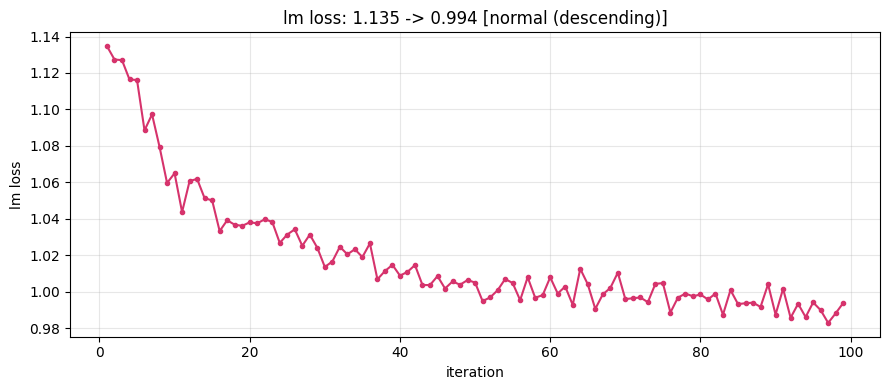

In [16]:
# 画 loss 曲线
if losses:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(9, 4))
    plt.plot(range(1, len(losses)+1), losses, color='#d6336c', lw=1.5, marker='o', ms=3)
    plt.xlabel('iteration')
    plt.ylabel('lm loss')
    trend = 'normal (descending)' if losses[-1] < losses[0] else 'ABNORMAL (check!)'
    plt.title(f'lm loss: {losses[0]:.3f} -> {losses[-1]:.3f} [{trend}]')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('暂无 loss 数据，训练完成后回到上一个 cell 重新运行。')

### 5.3 怎么看结果

| 信号 | 正常 | 异常 |
|------|------|------|
| **loss 趋势** | 持续下降（如 10→3） | 震荡 / 变 NaN → 检查学习率 |
| **吞吐量** | 稳定在某个值附近 | 忽高忽低 → 可能有卡掉队 |
| **单步耗时** | 各步基本一致 | 某步突然变慢 → 通信或 IO 瓶颈 |

---

## 小结

到这里，多卡分布式训练的五步闭环全部执行完毕。

**要点回顾**：
- 权重转换的本质是**按并行策略切分参数**（TP 切列、PP 切层）
- 数据预处理是把文本变成**数字序列**
- torchrun 负责**拉起多进程**，每张卡对应一个进程
- 日志里的 loss 曲线直接反映训练状态

**思考题**（写进实验报告）：
1. 为什么 TP×PP 必须 ≤ 总卡数？如果在 4 卡上设 TP=4 PP=2 会发生什么？
2. 如果你把 seq_length 从 8192 改成 32768，显存和速度会有什么变化？
3. loss 曲线如果「先降后平」，说明什么？该怎么继续优化？

> 注意：**训练完成后，请立即在 ModelArts 控制台停止实例**，避免持续计费。